In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.ndimage import sobel, gaussian_filter


In [6]:
def harris_corners_from_scratch(gray_img, block_size=3, k=0.04, threshold_ratio=0.01):

    # Compute image gradients
    Ix = sobel(gray_img, axis=1)
    Iy = sobel(gray_img, axis=0)

    # Products of derivatives
    Ixx = gaussian_filter(Ix * Ix, sigma=1)
    Iyy = gaussian_filter(Iy * Iy, sigma=1)
    Ixy = gaussian_filter(Ix * Iy, sigma=1)

    # Structure tensor sums
    Sxx = np.zeros_like(gray_img)
    Syy = np.zeros_like(gray_img)
    Sxy = np.zeros_like(gray_img)

    half = block_size // 2
    for y in range(half, gray_img.shape[0] - half):
        for x in range(half, gray_img.shape[1] - half):
            Sxx[y, x] = np.sum(Ixx[y-half:y+half+1, x-half:x+half+1])
            Syy[y, x] = np.sum(Iyy[y-half:y+half+1, x-half:x+half+1])
            Sxy[y, x] = np.sum(Ixy[y-half:y+half+1, x-half:x+half+1])

    # Harris response
    det = Sxx * Syy - Sxy ** 2
    trace = Sxx + Syy
    R = det - k * trace ** 2

    threshold = threshold_ratio * R.max()
    corners = []

    # Non-maximum suppression
    for y in range(1, R.shape[0] - 1):
        for x in range(1, R.shape[1] - 1):
            if R[y, x] > threshold:
                if R[y, x] == np.max(R[y-1:y+2, x-1:x+2]):
                    corners.append((y, x))

    return corners


In [7]:
def fast_corners_from_scratch(gray_img, threshold=30, n=9):

    gray_img = gray_img.astype(np.uint8)
    height, width = gray_img.shape
    corners = []

    # FAST circle (radius = 3)
    circle = [
        (0, 3), (1, 3), (2, 2), (3, 1), (3, 0), (3, -1), (2, -2), (1, -3),
        (0, -3), (-1, -3), (-2, -2), (-3, -1), (-3, 0), (-3, 1), (-2, 2), (-1, 3)
    ]

    for y in range(3, height - 3):
        for x in range(3, width - 3):

            center = int(gray_img[y, x])   # FIX: convert to int
            consec_bright = 0
            consec_dark = 0
            max_bright = 0
            max_dark = 0

            for dx, dy in circle:
                p = int(gray_img[y + dy, x + dx])  # FIX: convert to int

                if p > center + threshold:
                    consec_bright += 1
                    consec_dark = 0
                elif p < center - threshold:
                    consec_dark += 1
                    consec_bright = 0
                else:
                    consec_bright = consec_dark = 0

                max_bright = max(max_bright, consec_bright)
                max_dark = max(max_dark, consec_dark)

            if max_bright >= n or max_dark >= n:
                corners.append((y, x))

    return corners


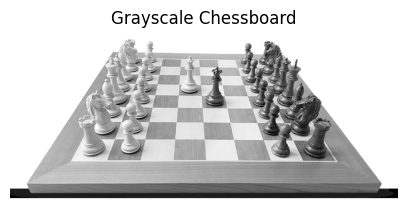

In [8]:
img_path = "/content/chessboard.png"   # Colab path
original = cv2.imread(img_path)

if original is None:
    raise FileNotFoundError("Chessboard image not found")

gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(5,5))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Chessboard")
plt.axis("off")
plt.show()


In [9]:
harris_pts = harris_corners_from_scratch(gray.astype(np.float32))
fast_pts = fast_corners_from_scratch(gray, threshold=30, n=9)

print("Harris corners:", len(harris_pts))
print("FAST corners:", len(fast_pts))


Harris corners: 517
FAST corners: 3924


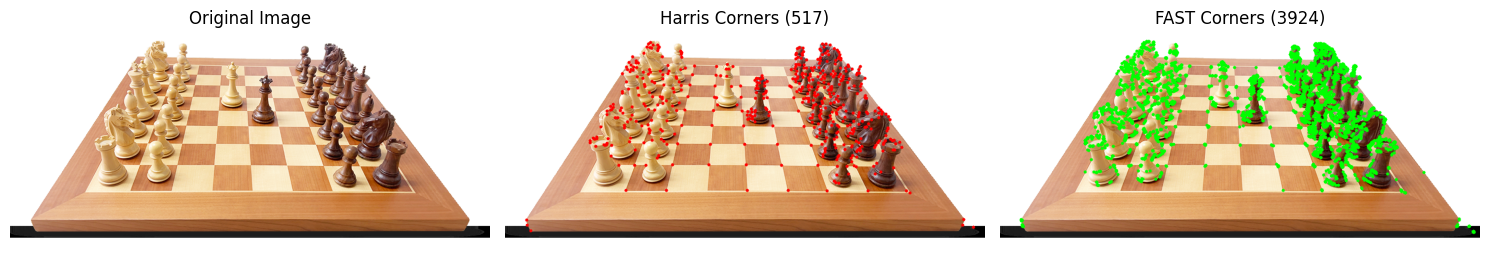

In [10]:
img_harris = original.copy()
for y, x in harris_pts:
    cv2.circle(img_harris, (x, y), 3, (0, 0, 255), -1)

img_fast = original.copy()
for y, x in fast_pts:
    cv2.circle(img_fast, (x, y), 3, (0, 255, 0), -1)

plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(img_harris, cv2.COLOR_BGR2RGB))
plt.title(f"Harris Corners ({len(harris_pts)})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(img_fast, cv2.COLOR_BGR2RGB))
plt.title(f"FAST Corners ({len(fast_pts)})")
plt.axis("off")

plt.tight_layout()
plt.show()
